In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving wdbc.data to wdbc.data


In [ ]:
# Load dataset
df = pd.read_csv('wdbc.data', header=None)

# Assign column names for clarity (optional)
columns = ['ID', 'Diagnosis'] + [f'feature_{i}' for i in range(1, 31)]
df.columns = columns

# Drop ID column
df = df.drop(columns=['ID'])


In [ ]:
# Define target and features
TARGET_COLUMN = 'Diagnosis'
y = df[TARGET_COLUMN]              # Labels: 'M' or 'B'
X = df.drop(columns=[TARGET_COLUMN])

# Encode target labels
le = LabelEncoder()
y = le.fit_transform(y)  # 'M' → 1, 'B' → 0


In [ ]:
# Train-validation-test split
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.3, random_state=42, stratify=y_temp
)

# Scale features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val   = scaler.transform(X_val)
X_test  = scaler.transform(X_test)

# Reshape for 1D CNN: (samples, features, 1)
X_train = X_train[..., np.newaxis]
X_val = X_val[..., np.newaxis]
X_test = X_test[..., np.newaxis]

print(f"Train shape: {X_train.shape}, Val shape: {X_val.shape}, Test shape: {X_test.shape}")

Train shape: (398, 30, 1), Val shape: (119, 30, 1), Test shape: (52, 30, 1)


In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

inputs = keras.Input(shape=(X_train.shape[1], 1))
x = layers.GaussianNoise(0.01)(inputs)
x = layers.Conv1D(64, 5, activation="relu", padding="same")(x)
x = layers.Conv1D(128, 3, activation="relu", padding="same")(x)
x = layers.MaxPooling1D()(x)
x = layers.Dropout(0.3)(x)

x = layers.Conv1D(256, 3, activation="relu", padding="same")(x)
x = layers.GlobalAveragePooling1D()(x)
x = layers.Dense(128, activation="relu")(x)
x = layers.Dropout(0.4)(x)

num_classes = len(np.unique(y))  # Should be 2 (M and B)
outputs = layers.Dense(num_classes, activation="softmax")(x)

model = keras.Model(inputs, outputs)
model.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()



Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 30, 1)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gaussian_noise (GaussianNoise)  │ (None, 30, 1)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 30, 64)         │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 30, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 15, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 15, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 15, 256)        │        98,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 156,802 (612.51 KB)

 Trainable params: 156,802 (612.51 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=40,
    batch_size=32,
    callbacks=[
        keras.callbacks.EarlyStopping(patience=10, restore_best_weights=True),
        keras.callbacks.ReduceLROnPlateau(patience=5, factor=0.5, min_lr=1e-6),
    ]
)


Epoch 1/40
13/13 ━━━━━━━━━━━━━━━━━━━━ 14s 658ms/step - accuracy: 0.7886 - loss: 0.5433 - val_accuracy: 0.8739 - val_loss: 0.2641 - learning_rate: 0.0010
Epoch 2/40
13/13 ━━━━━━━━━━━━━━━━━━━━ 8s 16ms/step - accuracy: 0.9037 - loss: 0.3093 - val_accuracy: 0.8824 - val_loss: 0.2416 - learning_rate: 0.0010
Epoch 3/40
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9000 - loss: 0.2671 - val_accuracy: 0.9076 - val_loss: 0.2380 - learning_rate: 0.0010
Epoch 4/40
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.8754 - loss: 0.3176 - val_accuracy: 0.9076 - val_loss: 0.2171 - learning_rate: 0.0010
Epoch 5/40
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9219 - loss: 0.2479 - val_accuracy: 0.9160 - val_loss: 0.1999 - learning_rate: 0.0010
Epoch 6/40
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9282 - loss: 0.2116 - val_accuracy: 0.9076 - val_loss: 0.2056 - learning_rate: 0.0010
Epoch 7/40
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9053 - loss: 0.2498 - val_a

In [ ]:
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=2)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")


2/2 - 1s - 322ms/step - accuracy: 0.9423 - loss: 0.1183
Test Loss: 0.1183
Test Accuracy: 0.9423


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

y_pred = model.predict(X_test).argmax(axis=1)

print("Classification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))



2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 284ms/step
Classification Report:
               precision    recall  f1-score   support

           0       0.94      0.97      0.96        33
           1       0.94      0.89      0.92        19

    accuracy                           0.94        52
   macro avg       0.94      0.93      0.94        52
weighted avg       0.94      0.94      0.94        52

Confusion Matrix:
 [[32  1]
 [ 2 17]]


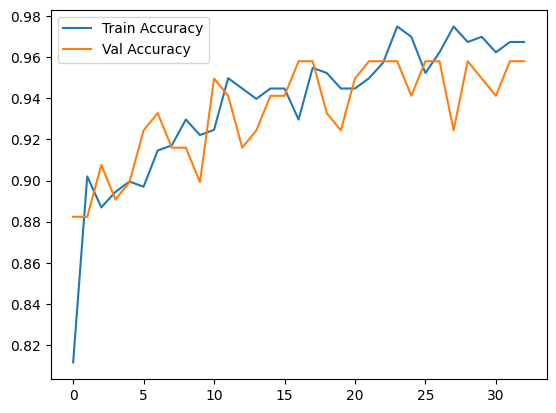

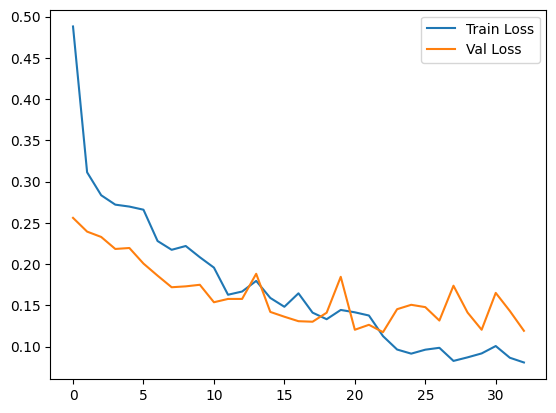

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.legend()
plt.show()

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.legend()
plt.show()



2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step


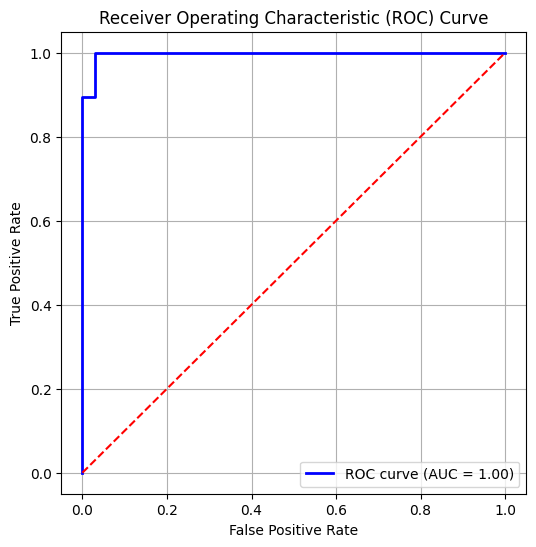

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# Predict probabilities for the test set
y_pred_proba = model.predict(X_test)

# If it's binary classification, get the probability for class 1
if y_pred_proba.shape[1] == 1:  # single output neuron with sigmoid
    y_pred_proba = y_pred_proba.ravel()
else:  # softmax output
    y_pred_proba = y_pred_proba[:, 1]

# Compute ROC curve and AUC
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

# Plot
plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f"ROC curve (AUC = {roc_auc:.2f})")
plt.plot([0, 1], [0, 1], color='red', linestyle='--')  # random line
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Receiver Operating Characteristic (ROC) Curve")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()


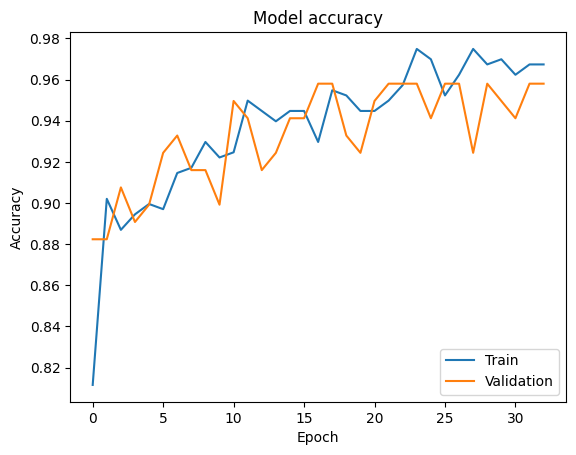

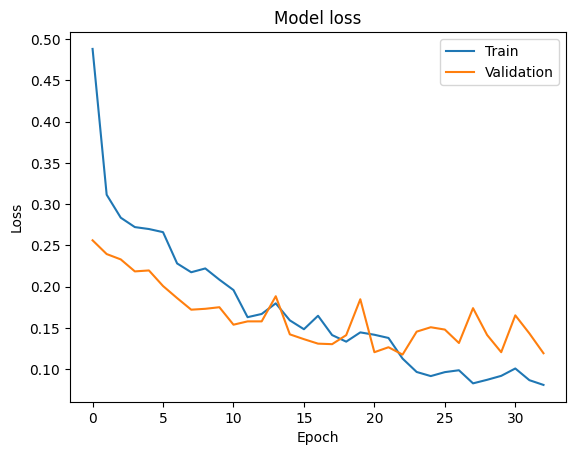

In [ ]:
import matplotlib.pyplot as plt

# Plot training & validation accuracy values
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='lower right')
plt.show()

# Plot training & validation loss values
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper right')
plt.show()
